In [168]:
import pandas as pd

data = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\Gene list\consensus_results.Retroviridae.txt",sep="\t")

In [169]:
from sklearn.preprocessing import normalize

# 標準化後算兩種機器學習的Shapley value的平均
data["RF_mean_nor"] = normalize(
    data[["RF_mean_abs_Score"]],
    axis=0
)

data["XGB_mean_nor"] = normalize(
    data[["XGB_mean_abs_Score"]],
    axis=0
)

data["AVG_mean"] = (data["XGB_mean_nor"] + data["RF_mean_nor"])/2

In [170]:
print(data[["Gene","RF_mean_abs_Score","XGB_mean_abs_Score","RF_mean_nor","XGB_mean_nor","AVG_mean"]].head())

     Gene  RF_mean_abs_Score  XGB_mean_abs_Score  RF_mean_nor  XGB_mean_nor  \
0   NR4A3           0.003514            0.418064     0.392577      0.544666   
1   CXCL2           0.001526            0.283132     0.170504      0.368872   
2    ASTL           0.002337            0.281736     0.261024      0.367054   
3  NAP1L5           0.001146            0.321239     0.127989      0.418519   
4  TNFSF9           0.001159            0.135114     0.129444      0.176030   

   AVG_mean  
0  0.468621  
1  0.269688  
2  0.314039  
3  0.273254  
4  0.152737  


In [171]:
# 先將想分析的欄位取出來，當作enrichment的ranking，之後可以調整
col = "RF_mean_abs_Score"

rf_rank = data[["Gene",col]]

print(rf_rank.head())

print(len(rf_rank)) # 39376個基因

     Gene  RF_mean_abs_Score
0   NR4A3           0.003514
1   CXCL2           0.001526
2    ASTL           0.002337
3  NAP1L5           0.001146
4  TNFSF9           0.001159
39376


In [172]:
# 很多基因的數值為0

rf_rank = rf_rank.loc[rf_rank[col] != 0,:]

print(len(rf_rank)) 

6380


In [173]:
rf_rank.columns = ["gene", "score"] # 換col名稱 不確定需不需要

rf_rank = rf_rank.sort_values(
    by="score",
    ascending=False
)

print(rf_rank.head())

      gene     score
0    NR4A3  0.003514
2     ASTL  0.002337
1    CXCL2  0.001526
107  DUSP8  0.001362
23   NRARP  0.001258


In [174]:
# 取出排名前50的基因
rf_rank_top_100 = rf_rank.iloc[0:50,0:2] 

print(rf_rank_top_100.head())

      gene     score
0    NR4A3  0.003514
2     ASTL  0.002337
1    CXCL2  0.001526
107  DUSP8  0.001362
23   NRARP  0.001258


In [175]:
rf_gene_list = rf_rank_top_100["gene"].tolist() # 可以做OSA
print(rf_gene_list[:5])

['NR4A3', 'ASTL', 'CXCL2', 'DUSP8', 'NRARP']


In [176]:
# Pathway database
db = "Reactome_2022"

import gseapy as gp

# 先做OSA
res = gp.enrichr(
    gene_list=rf_gene_list, 
    gene_sets=db
)

# 再做GSEA
res_2 = gp.prerank(
    rnk=rf_rank,
    gene_sets=db,
    permutation_num=1000,
    seed=123,
    outdir=None
)

In [177]:
print(res.results.sort_values(
    by="Adjusted P-value",
    ascending=True
).head())

        Gene_set                                               Term Overlap  \
0  Reactome_2022             Interleukin-10 Signaling R-HSA-6783783    4/45   
1  Reactome_2022    RAF-independent MAPK1/3 Activation R-HSA-112409    2/23   
2  Reactome_2022  EGR2 And SOX10-mediated Initiation Of Schwann ...    2/29   
3  Reactome_2022  Interleukin-4 And Interleukin-13 Signaling R-H...   3/107   
4  Reactome_2022  Synthesis Of Substrates In N-glycan Biosythesi...    2/63   

    P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0  0.000005          0.000544            0                     0   42.224814   
1  0.001499          0.069277            0                     0   39.541667   
2  0.002382          0.069277            0                     0   30.745370   
3  0.002431          0.069277            0                     0   12.180442   
4  0.010855          0.154842            0                     0   13.585383   

   Combined Score                 Genes  
0 

In [178]:
ora_df = res.results.copy()


# 取顯著 pathway
sig_df = ora_df[
    ora_df["Adjusted P-value"] < 0.05
].copy()


# 依顯著性排序
sig_df = sig_df.sort_values(
    "Adjusted P-value",
    ascending=True
)


print(sig_df.head())
len(sig_df)

        Gene_set                                    Term Overlap   P-value  \
0  Reactome_2022  Interleukin-10 Signaling R-HSA-6783783    4/45  0.000005   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.000544            0                     0   42.224814   

   Combined Score                 Genes  
0      517.352516  IL1A;IL6;IL12A;CXCL2  


1

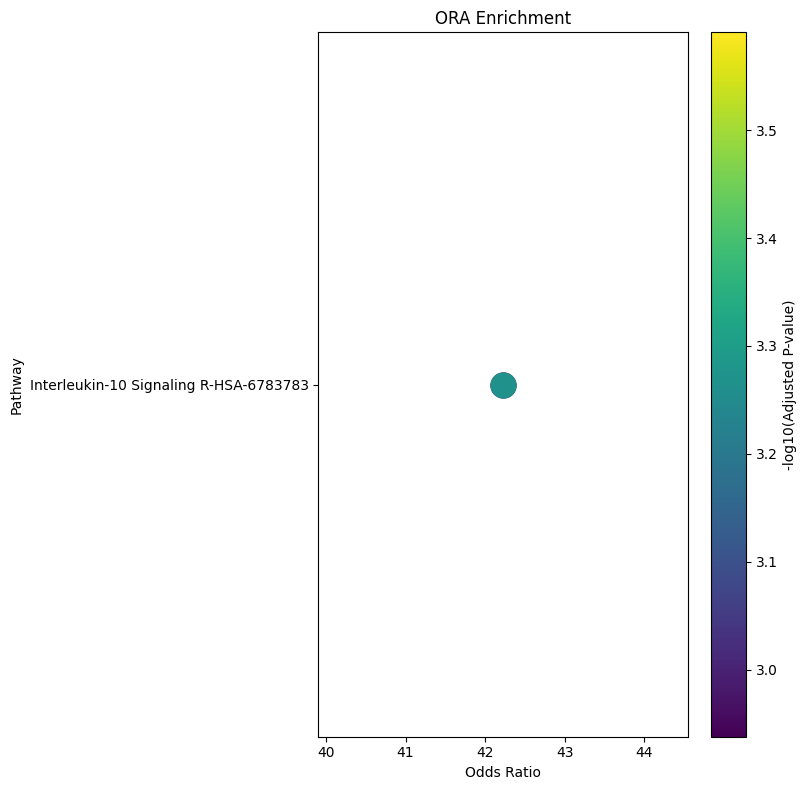

In [179]:
import numpy as np
import matplotlib.pyplot as plt


plot_df = sig_df.copy()


# overlap gene數量
plot_df["Gene_count"] = (
    plot_df["Overlap"]
    .str.split("/")
    .str[0]
    .astype(int)
)


# -log10 FDR
plot_df["-log10(FDR)"] = (
    -np.log10(plot_df["Adjusted P-value"])
)


plt.figure(figsize=(8,8))


plt.scatter(
    plot_df["Odds Ratio"],
    plot_df["Term"],
    s=plot_df["Gene_count"]*80,
    c=plot_df["-log10(FDR)"],
)

scatter = plt.scatter(
    plot_df["Odds Ratio"],
    plot_df["Term"],
    s=plot_df["Gene_count"]*80,
    c=plot_df["-log10(FDR)"],
    cmap="viridis"
)

# 加入colorbar
cbar = plt.colorbar(scatter)

cbar.set_label(
    "-log10(Adjusted P-value)"
)

plt.xlabel(
    "Odds Ratio"
)

plt.ylabel(
    "Pathway"
)

plt.title(
    "ORA Enrichment"
)


plt.tight_layout()

plt.show()

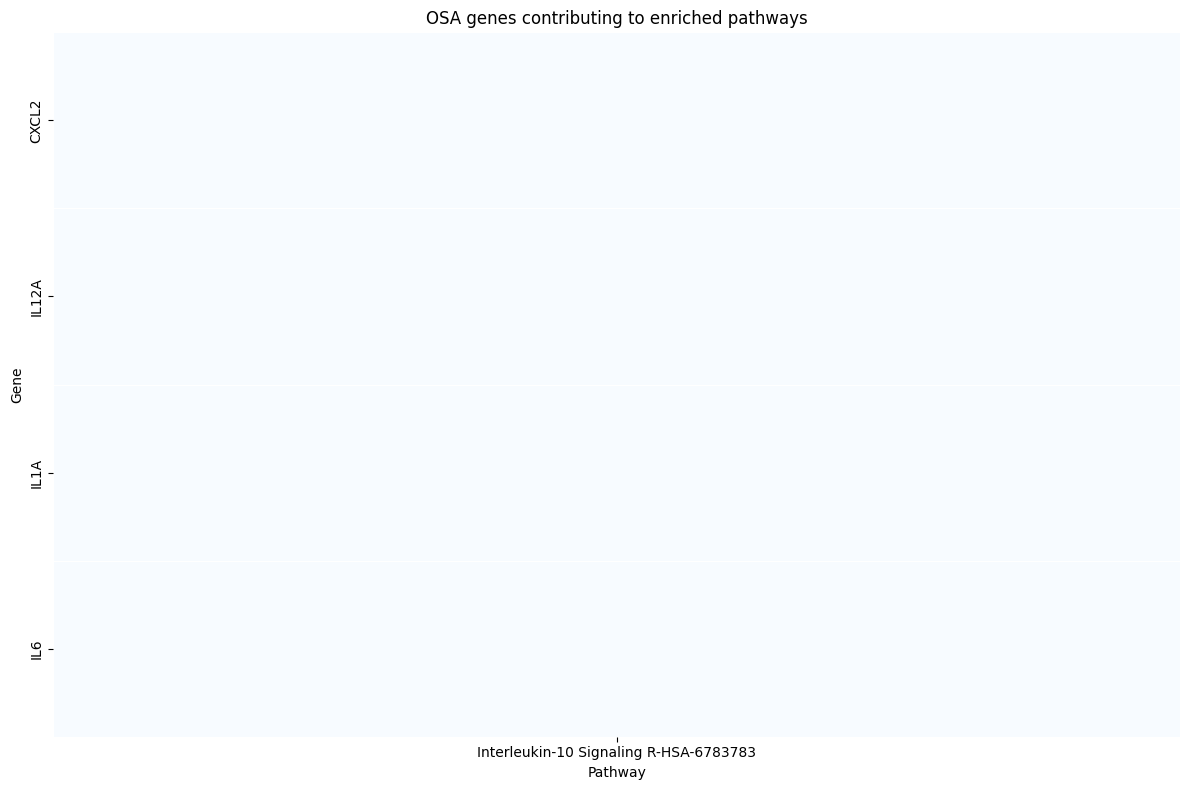

In [180]:
import seaborn as sns


top_pathway = sig_df


# 收集gene

all_genes = set()

for genes in top_pathway["Genes"]:

    all_genes.update(
        genes.split(";")
    )


all_genes = sorted(all_genes)



matrix = pd.DataFrame(
    0,
    index=all_genes,
    columns=top_pathway["Term"]
)



for _, row in top_pathway.iterrows():

    pathway = row["Term"]

    genes = row["Genes"].split(";")

    for gene in genes:

        matrix.loc[
            gene,
            pathway
        ] = 1



plt.figure(
    figsize=(12,8)
)


sns.heatmap(
    matrix,
    cmap="Blues",
    linewidths=0.5,
    cbar=False
)


plt.xlabel(
    "Pathway"
)

plt.ylabel(
    "Gene"
)


plt.title(
    "OSA genes contributing to enriched pathways"
)


plt.tight_layout()

plt.show()

In [181]:
print(res_2.res2d.sort_values(
    by="FDR q-val",
    ascending=True
).head())

       Name                                               Term        ES  \
0   prerank             Interleukin-10 Signaling R-HSA-6783783  0.914182   
1   prerank  RUNX1 Regulates Genes Involved In Megakaryocyt...  0.892851   
27  prerank                Platelet Degranulation R-HSA-114608 -0.282995   
2   prerank  Interleukin-4 And Interleukin-13 Signaling R-H...  0.834411   
3   prerank             Interleukin-12 Signaling R-HSA-9020591  0.829756   

         NES  NOM p-val  FDR q-val  FWER p-val  Tag %  Gene %  \
0   1.707851   0.000000   0.063570    0.027000   7/17   3.20%   
1   1.667989   0.002010   0.104791    0.101000   2/19   0.56%   
27 -1.257602   0.000000   0.268188    0.121107  23/23  71.82%   
2   1.596514   0.000000   0.333742    0.334000   5/34   1.39%   
3   1.547688   0.009193   0.526687    0.584000   3/15   1.69%   

                                           Lead_genes  
0                 CXCL2;IL12A;IL1A;IL6;IL10;LIF;CCL20  
1                                       

In [182]:
sig_gsea = res_2.res2d[
    res_2.res2d["FDR q-val"] < 0.25
]

sig_gsea = sig_gsea.sort_values(
    by="FDR q-val",
    ascending=True
)

print(sig_gsea)
len(sig_gsea)

      Name                                               Term        ES  \
0  prerank             Interleukin-10 Signaling R-HSA-6783783  0.914182   
1  prerank  RUNX1 Regulates Genes Involved In Megakaryocyt...  0.892851   

        NES  NOM p-val  FDR q-val  FWER p-val Tag % Gene %  \
0  1.707851    0.00000   0.063570       0.027  7/17  3.20%   
1  1.667989    0.00201   0.104791       0.101  2/19  0.56%   

                            Lead_genes  
0  CXCL2;IL12A;IL1A;IL6;IL10;LIF;CCL20  
1                          NR4A3;GATA1  


2

In [183]:
Lead_genes = sig_gsea["Lead_genes"].to_list()

Lead_genes

['CXCL2;IL12A;IL1A;IL6;IL10;LIF;CCL20', 'NR4A3;GATA1']

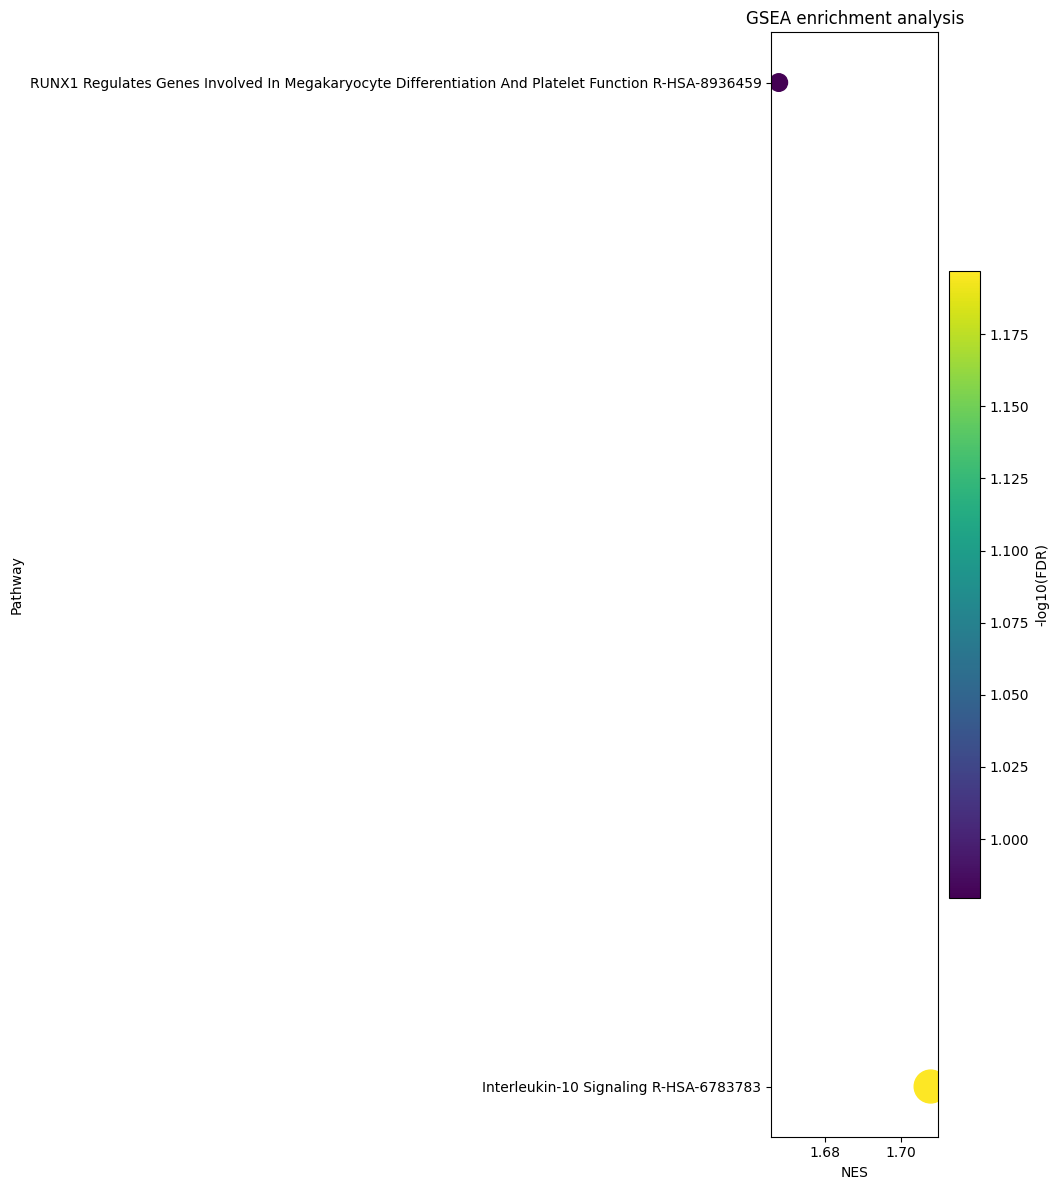

In [189]:
import matplotlib.pyplot as plt
import numpy as np


plot_df = sig_gsea.head(20).copy()


plot_df["Tag_count"] = (
    plot_df["Tag %"]
    .str.split("/")
    .str[0]
    .astype(int)
)


plt.figure(figsize=(10,12))


scatter = plt.scatter(
    plot_df["NES"],
    plot_df["Term"],
    s=plot_df["Tag_count"]*80,
    c=-np.log10(plot_df["FDR q-val"])
)


plt.colorbar(
    scatter,
    label="-log10(FDR)"
)


plt.xlabel(
    "NES"
)

plt.ylabel(
    "Pathway"
)


plt.title(
    "GSEA enrichment analysis"
)


plt.tight_layout()

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_25988\867787105.py:109: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


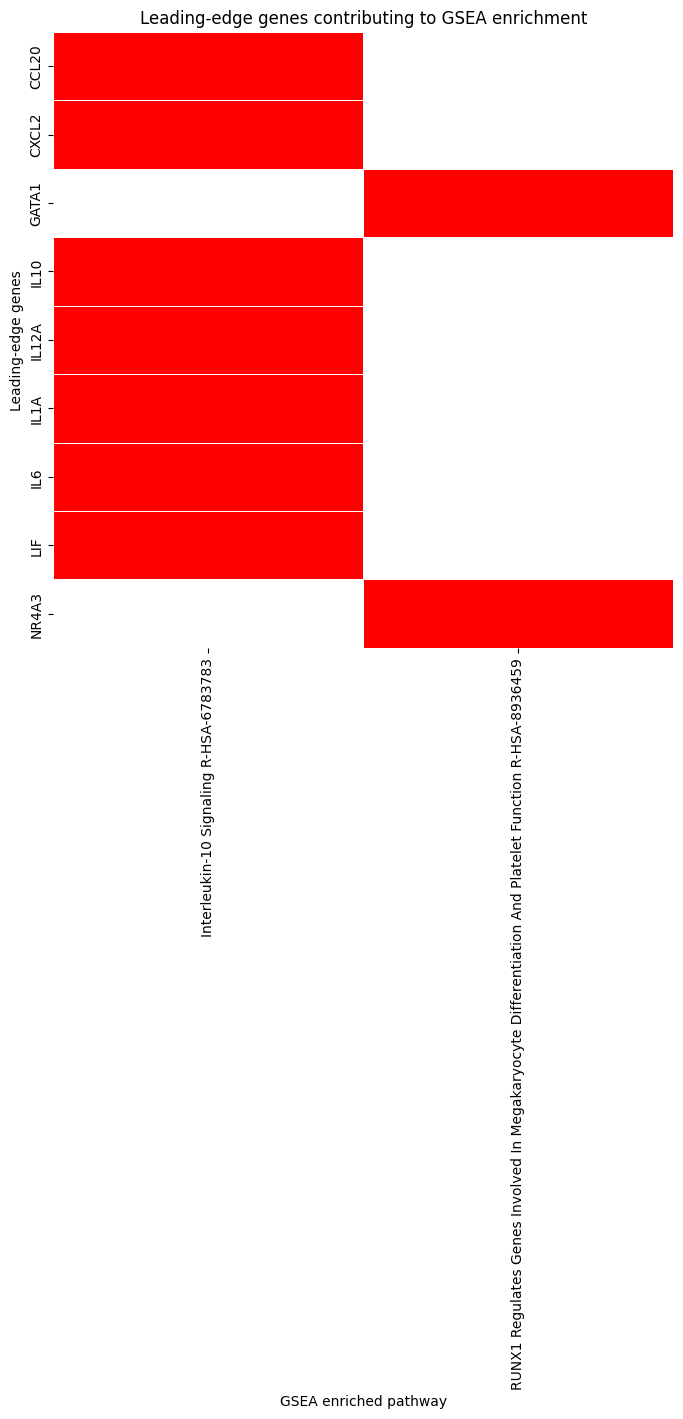

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap


top_pathway = sig_gsea.head(20).copy()


# =========================
# 收集 leading-edge genes
# =========================

all_genes = set()


for genes in top_pathway["Lead_genes"]:

    all_genes.update(
        genes.split(";")
    )


all_genes = sorted(all_genes)



# =========================
# 建立 0/1 matrix
# =========================

matrix = pd.DataFrame(
    0,
    index=all_genes,
    columns=top_pathway["Term"]
)



for _, row in top_pathway.iterrows():

    pathway = row["Term"]

    genes = row["Lead_genes"].split(";")


    for gene in genes:

        matrix.loc[
            gene,
            pathway
        ] = 1



# =========================
# gene排序
# 出現越多pathway越上面
# =========================

matrix = matrix.loc[
    matrix.sum(axis=1)
    .sort_values(ascending=False)
    .index
]



# =========================
# 畫binary heatmap
# =========================

plt.figure(
    figsize=(
        max(8, len(matrix.columns)*0.5),
        max(8, len(matrix.index)*0.35)
    )
)


cmap = ListedColormap(
    ["white", "red"]
)


sns.heatmap(
    matrix,
    cmap=cmap,
    linewidths=0.5,
    cbar=False
)


plt.xlabel(
    "GSEA enriched pathway"
)


plt.ylabel(
    "Leading-edge genes"
)


plt.title(
    "Leading-edge genes contributing to GSEA enrichment"
)


plt.tight_layout()

plt.show()